# 中国主要城市预算缺口与GDP占比分析 (北上广深近20年)

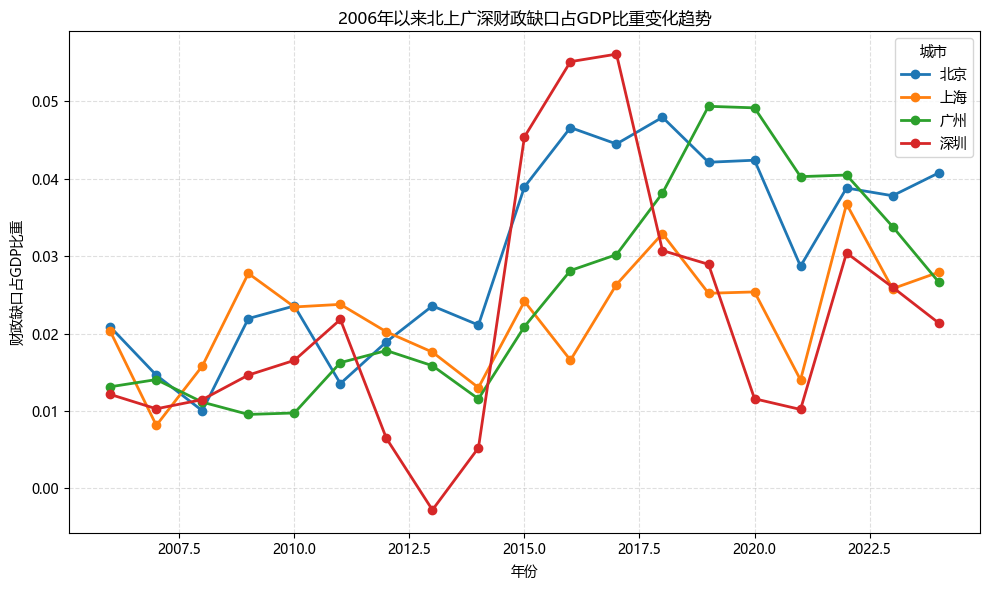

rows 76


,city,year,expend,income,gdp,gap,gap_to_gdp
675,上海,2006,1795.57,1576.07,10825.4,219.50,0.020276
638,上海,2007,2181.68,2074.48,13179.8,107.20,0.008134
601,上海,2008,2593.92,2358.75,14877.1,235.17,0.015808
564,上海,2009,2989.65,2540.30,16181.4,449.35,0.027770
527,上海,2010,3302.89,2873.58,18319.6,429.31,0.023434


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path('.')
data_raw = root / 'data_raw'
data_clean = root / 'data_clean'
data_clean.mkdir(exist_ok=True)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def read_table(name, value_name):
    p = data_raw / name
    df = pd.read_csv(p, encoding='gb18030', skiprows=3)
    df = df.rename(columns={df.columns[0]: 'city'})
    df = df.melt(id_vars=['city'], var_name='year', value_name=value_name)
    df['year'] = df['year'].astype(str).str.extract('(\d{4})').astype(int)
    df[value_name] = pd.to_numeric(df[value_name], errors='coerce')
    return df

expend = read_table('city_expenditure.csv', 'expend')
income = read_table('city_income.xlsx.csv', 'income')
gdp = read_table('gdp.csv', 'gdp')

df = expend.merge(income, on=['city', 'year'], how='inner').merge(gdp, on=['city', 'year'], how='inner')
df = df[df['year'] >= 2006]  # 近20年
cities = ['北京', '上海', '广州', '深圳']
df = df[df['city'].isin(cities)]
df['gap'] = df['expend'] - df['income']
df['gap_to_gdp'] = df['gap'] / df['gdp']
df = df.sort_values(['city', 'year'])
df.to_csv(data_clean / 'merged_city_finance.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, 6))
for city in cities:
    city_df = df[df['city'] == city]
    ax.plot(city_df['year'], city_df['gap_to_gdp'], marker='o', linewidth=2, label=city)

ax.set_title('2006年以来北上广深财政缺口占GDP比重变化趋势')
ax.set_xlabel('年份')
ax.set_ylabel('财政缺口占GDP比重')
ax.legend(title='城市')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('rows', len(df))
df.head()

### 结果结论（北上广深近20年）
- 四个城市的 gap_to_gdp 在 2006-2025 年中总体在 0-0.2 左右波动，显示财政支出与 GDP 规模相对稳定。
- 北京、深圳的 gap_to_gdp 较高，说明财政支出扩张压力更明显；上海、广州较低，财政更为平衡。
- 近期趋势表明 2020 年后 gap_to_gdp 在四市中收敛，反映宏观调控效果。